In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error


In [79]:
df=pd.read_csv('Microsoft_Stock.csv')
df=df.set_index('Date')
df.index=pd.to_datetime(df.index)
index1='2015-04-01 16:00:00'
index2='2016-04-01 16:00:00'

# adfuller test to check if close is stationary or not.

In [80]:
result=adfuller(df['Close'])
if result[1]>0.05:
    print("Non Stationary")
else:
    print("Stationay")

Non Stationary


In [81]:
def create_features(df):
    df['Year']=df.index.year
    df['Month']=df.index.month
    df['Day of Week']=df.index.dayofweek
    df['Diff']=df['Close'].diff()
    df['lag1']=df['Diff'].shift(1)
    df['lag7']=df['Diff'].shift(7)
    df['lag30']=df['Diff'].shift(30)
    df['running_mean7']=df['Close'].rolling(window=7).mean()
    df['running_std7']=df['Close'].rolling(window=7).std()
    df['running_mean30']=df['Close'].rolling(window=30).mean()
    df['running_std30']=df['Close'].rolling(window=30).std()
    return df
df=create_features(df)
df=df.dropna()
    

# EDA

In [82]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1480 entries, 2015-05-15 16:00:00 to 2021-03-31 16:00:00
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Open            1480 non-null   float64
 1   High            1480 non-null   float64
 2   Low             1480 non-null   float64
 3   Close           1480 non-null   float64
 4   Volume          1480 non-null   int64  
 5   Year            1480 non-null   int32  
 6   Month           1480 non-null   int32  
 7   Day of Week     1480 non-null   int32  
 8   Diff            1480 non-null   float64
 9   lag1            1480 non-null   float64
 10  lag7            1480 non-null   float64
 11  lag30           1480 non-null   float64
 12  running_mean7   1480 non-null   float64
 13  running_std7    1480 non-null   float64
 14  running_mean30  1480 non-null   float64
 15  running_std30   1480 non-null   float64
dtypes: float64(12), int32(3), int64(1)
memory 

In [83]:
df.corr().style.background_gradient(cmap='coolwarm')

,Open,High,Low,Close,Volume,Year,Month,Day of Week,Diff,lag1,lag7,lag30,running_mean7,running_std7,running_mean30,running_std30
Open,1.000000,0.999770,0.999751,0.999531,0.072341,0.935894,-0.033158,-0.005921,0.028150,0.046903,0.043435,0.041653,0.999083,0.667831,0.996098,0.730994
High,0.999770,1.000000,0.999613,0.999724,0.080898,0.936148,-0.035018,-0.006338,0.036894,0.042036,0.043063,0.043194,0.999194,0.675263,0.996679,0.735913
Low,0.999751,0.999613,1.000000,0.999762,0.062371,0.935675,-0.032186,-0.006141,0.039939,0.045862,0.044704,0.043087,0.998865,0.661763,0.995655,0.726577
Close,0.999531,0.999724,0.999762,1.000000,0.070093,0.935981,-0.033831,-0.006442,0.052606,0.038346,0.045737,0.043651,0.998916,0.667442,0.996042,0.731035
Volume,0.072341,0.080898,0.062371,0.070093,1.000000,0.059789,-0.125353,0.097590,-0.068206,-0.072044,-0.047674,0.026766,0.078060,0.466504,0.095529,0.337612
Year,0.935894,0.936148,0.935675,0.935981,0.059789,1.000000,-0.210493,-0.002183,0.033746,0.031257,0.033243,0.038664,0.936186,0.632432,0.936277,0.692755
Month,-0.033158,-0.035018,-0.032186,-0.033831,-0.125353,-0.210493,1.000000,-0.015610,-0.007922,-0.006899,-0.002193,-0.009696,-0.033257,-0.086529,-0.031102,-0.153949
Day of Week,-0.005921,-0.006338,-0.006141,-0.006442,0.097590,-0.002183,-0.015610,1.000000,-0.007580,-0.007352,0.005519,-0.003018,-0.006055,-0.009070,-0.006127,-0.004884
Diff,0.028150,0.036894,0.039939,0.052606,-0.068206,0.033746,-0.007922,-0.007580,1.000000,-0.275697,0.144479,0.058860,0.023097,-0.006269,0.024281,0.000712
lag1,0.046903,0.042036,0.045862,0.038346,-0.072044,0.031257,-0.006899,-0.007352,-0.275697,1.000000,-0.120306,-0.005542,0.023515,0.004033,0.021914,0.008680


<Axes: xlabel='Date'>

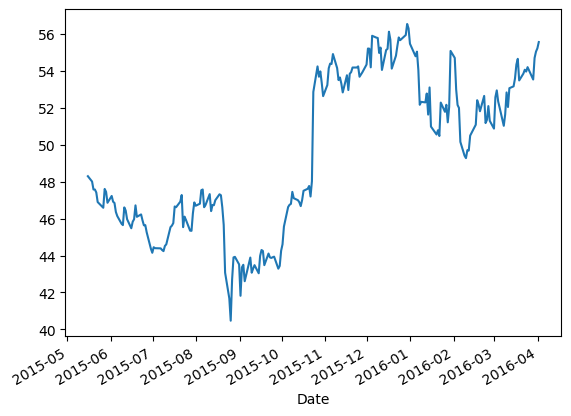

In [84]:
df['Close'].loc[index1:index2].plot()

Autocorrelation of close


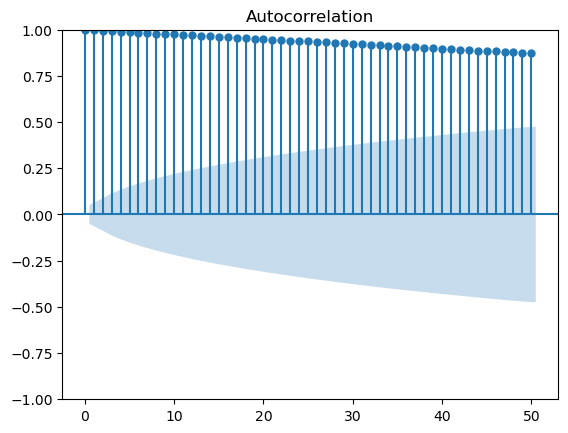

Autocorrelation of Diff


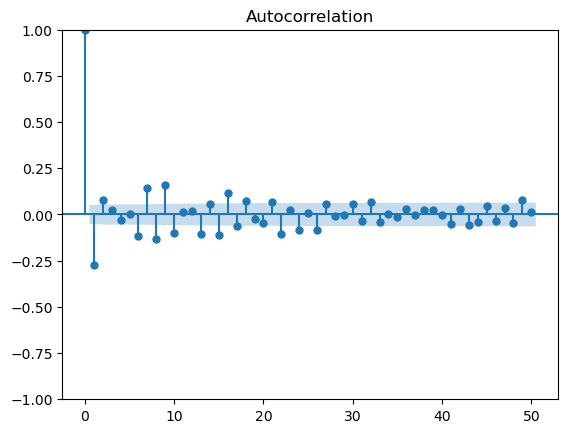

In [85]:
plot_acf(df['Close'],lags=50)
print("Autocorrelation of close")
plt.show()
plot_acf(df['Diff'],lags=50)
print("Autocorrelation of Diff")
plt.show()

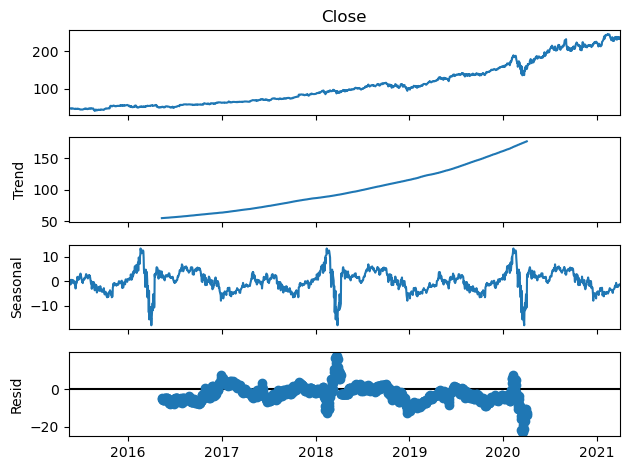

In [86]:
result=seasonal_decompose(df['Close'],period=500,model='additive')
result.plot()
plt.show()

# Features for training and testing

In [87]:
features=['Volume','Year','Month','Day of Week','lag1','lag7','lag30','running_mean7','running_std7','running_mean30','running_std30']
target='Diff'


# Train-Test Split

In [88]:
split=int(len(df)*0.8)
train, test=df[:split],df[split:]
train.shape,test.shape

((1184, 16), (296, 16))

# MODEL

In [89]:
model=xgb.XGBRegressor(n_estimators=1000,learning_rate=0.01,early_stopping_rounds=50)
model.fit(train[features],train[target],eval_set=[(train[features],train[target]),(test[features],test[target])])
test=test.copy()
test['predicted_diff']=model.predict(test[features])

[0]	validation_0-rmse:1.24608	validation_1-rmse:4.68417
[1]	validation_0-rmse:1.24214	validation_1-rmse:4.68224
[2]	validation_0-rmse:1.23826	validation_1-rmse:4.68040
[3]	validation_0-rmse:1.23487	validation_1-rmse:4.67871
[4]	validation_0-rmse:1.23153	validation_1-rmse:4.67710
[5]	validation_0-rmse:1.22824	validation_1-rmse:4.67557
[6]	validation_0-rmse:1.22499	validation_1-rmse:4.67443
[7]	validation_0-rmse:1.22179	validation_1-rmse:4.67302
[8]	validation_0-rmse:1.21863	validation_1-rmse:4.67202
[9]	validation_0-rmse:1.21551	validation_1-rmse:4.67068
[10]	validation_0-rmse:1.21196	validation_1-rmse:4.66973
[11]	validation_0-rmse:1.20892	validation_1-rmse:4.66893
[12]	validation_0-rmse:1.20540	validation_1-rmse:4.66708
[13]	validation_0-rmse:1.20197	validation_1-rmse:4.66593
[14]	validation_0-rmse:1.19893	validation_1-rmse:4.66416
[15]	validation_0-rmse:1.19588	validation_1-rmse:4.66357
[16]	validation_0-rmse:1.19284	validation_1-rmse:4.66278
[17]	validation_0-rmse:1.18970	validation

<Axes: >

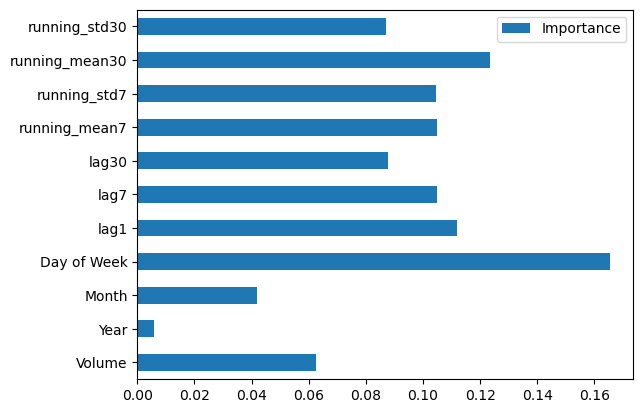

In [90]:
fi_df=pd.DataFrame(data=model.feature_importances_,index=model.feature_names_in_,columns=['Importance'])
fi_df.plot(kind='barh')

In [91]:
last_train_close=train['Close'].iloc[-1]
predicted_close=[last_train_close]
for d in test['predicted_diff']:
    predicted_close.append(predicted_close[-1]+d)
test['predicted_close']=predicted_close[1:]
df=df.merge(test[['predicted_close']],how='right',right_index=True,left_index=True)
df

,Open,High,Low,Close,Volume,Year,Month,Day of Week,Diff,lag1,lag7,lag30,running_mean7,running_std7,running_mean30,running_std30,predicted_close
Date,,,,,,,,,,,,,,,,,
2020-01-29 16:00:00,167.84,168.75,165.69,168.04,35127771,2020,1,2,2.58,3.18,0.93,1.29,165.677143,1.795455,160.879667,4.082718,164.996717
2020-01-30 16:00:00,174.05,174.05,170.79,172.78,51597470,2020,1,3,4.74,2.58,-0.60,1.00,166.574286,3.252726,161.454667,4.497007,163.966169
2020-01-31 16:00:00,172.21,172.40,169.58,170.23,36142690,2020,1,4,-2.55,4.74,-0.80,-0.84,167.221429,3.491649,161.972667,4.585078,164.976906
2020-02-03 16:00:00,170.43,174.50,170.40,174.38,30149052,2020,2,0,4.15,-2.55,1.02,-0.32,168.315714,4.392440,162.639667,4.886505,165.639672
2020-02-04 16:00:00,177.14,180.64,176.31,180.12,36433339,2020,2,1,5.74,4.15,-1.68,1.34,170.470000,5.942578,163.453333,5.663373,166.252962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-25 16:00:00,235.30,236.94,231.57,232.34,34061853,2021,3,3,-3.12,-2.12,2.90,-0.95,234.211429,3.018644,235.367000,5.197427,237.352470
2021-03-26 16:00:00,231.55,236.71,231.55,236.48,25479853,2021,3,4,4.14,-3.12,-0.67,1.67,234.131429,2.937518,235.100000,4.910422,238.055535
2021-03-29 16:00:00,236.59,236.80,231.88,235.24,25227455,2021,3,0,-1.24,4.14,-6.32,0.50,234.777143,2.531355,234.775000,4.542117,237.993041


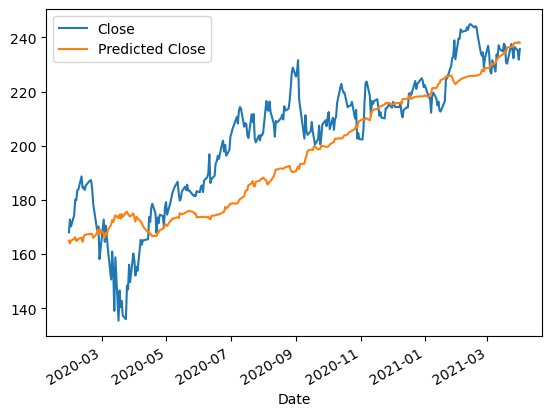

In [92]:
ax=df[['Close']].plot(label='Actual Close')
df['predicted_close'].plot(ax=ax,label='Predicted Close')
plt.legend()
plt.show()

In [94]:
score=mean_squared_error(test['Close'],test['predicted_close'])
print(f"Test Score: {score:.2f}")
score_rmse = root_mean_squared_error(test['Close'], test['predicted_close'])
score_rmse

Test Score: 231.92


15.228809065229784